# Credit Card Reward Optimisation
## 40.018 Heuristics and Systems Theory — Project 1

**Group:** Sheil Ketan Mistry · Farid Bin Zahairi · Kavya Santosh Nair

This notebook formulates the credit card wallet selection and monthly allocation problem as a Mixed-Integer Linear Programme (MILP) and demonstrates that exact solvers become intractable as the card pool grows. A **Simulated Annealing (SA)** metaheuristic is implemented as the main solver for large instances. SA is benchmarked against the Gurobi optimal on small instances to quantify solution quality. Monthly spending is drawn from lognormal distributions calibrated to HES 2023 data, breaking the month-to-month symmetry that would otherwise make the problem trivial.

## Import Packages

| Package | Purpose |
|---|---|
| `json` | Load card data from file |
| `random` | SA random moves and reproducibility |
| `time` | Wall-clock timing for convergence tracking |
| `math` | Metropolis acceptance probability (`exp`) |
| `copy` | Shallow-copy wallet and allocation on improvement |
| `numpy` | Lognormal spend sampling, numerical operations |
| `pandas` | Display results as formatted tables |
| `matplotlib.pyplot` | Convergence and comparison plots |
| `IPython.display` | Live output updates during SA loop |
| `gurobipy` | MILP solver (academic license) |

In [1]:
import json
import random
import time
import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import gurobipy as gp
from gurobipy import GRB
from dataclasses import dataclass

## 1. Data

### 1.1 Card Data

Eleven real Singapore cards from MoneySmart (June 2026). To run scalability experiments we augment the pool with **synthetic cards** whose parameters are sampled uniformly from ranges observed in the real data. Synthetic cards are given finite per-category caps (25%–85% of the maximum reward earnable per category at mean spend) and overall caps (S$30–100), unlike the real cards which are mostly uncapped — this makes the large-instance problem genuinely harder and ensures the caps actually bind for high-rate synthetic cards.

### 1.2 Monthly Spending

Spending in category $k$ in month $m$ is drawn independently:

$$s_{km} \sim \text{LogNormal}(\mu_k,\, \sigma_k)$$

where $\mu_k$ and $\sigma_k$ are calibrated to HES 2023 median expenditure by income quintile. This breaks month-to-month symmetry: the optimal allocation in month 3 (high dining spend) may differ from month 7 (high travel spend), so the 24-month problem cannot be collapsed to a single representative month.

Three spending profiles are defined: **young professional** (quintile 2–3), **couple** (quintile 3–4), **family** (quintile 4–5).


In [2]:
CATEGORIES = ['dining', 'groceries', 'online', 'transport', 'utilities', 'travel']
H     = 24    # planning horizon in months
W_MAX = 3     # maximum wallet size

@dataclass
class Card:
    id:           str
    name:         str
    annual_fee:   float
    min_income:   float
    min_spend:    float
    overall_cap:  float
    rates:        dict
    category_caps: dict

def load_real_cards(path='data/cards.json'):
    with open(path) as f:
        data = json.load(f)
    return [
        Card(id=d['id'], name=d['name'], annual_fee=d['annual_fee'],
             min_income=d['min_income'], min_spend=d['min_spend'],
             overall_cap=d['overall_cap'], rates=d['rates'],
             category_caps=d['category_caps'])
        for d in data
    ]

def generate_synthetic_cards(n, real_cards, seed=42):
    rng     = np.random.default_rng(seed)
    rate_lo = {k: min(c.rates[k] for c in real_cards) for k in CATEGORIES}
    rate_hi = {k: max(c.rates[k] for c in real_cards) for k in CATEGORIES}
    # Reference mean spend (young professional) for cap calibration
    mean_spend_ref = {'dining': 400, 'groceries': 250, 'online': 300,
                      'transport': 200, 'utilities': 150, 'travel': 100}
    # Max reward a card can earn per category at mean spend;
    # category_caps and overall_cap are set to bind for high-rate cards
    cat_cap_hi = {k: rate_hi[k] * mean_spend_ref[k] for k in CATEGORIES}
    cards   = []
    for i in range(n):
        cards.append(Card(
            id=f'synth_{i}',
            name=f'Synthetic {i}',
            annual_fee=float(rng.uniform(0.0, 196.2)),
            min_income=float(rng.uniform(0.0, 30000.0)),
            min_spend=float(rng.uniform(0.0, 1600.0)),
            overall_cap=float(rng.uniform(30.0, 100.0)),
            rates={k: float(rng.uniform(rate_lo[k], rate_hi[k])) for k in CATEGORIES},
            category_caps={k: float(rng.uniform(0.25 * cat_cap_hi[k], 0.85 * cat_cap_hi[k]))
                           for k in CATEGORIES},
        ))
    return cards

# HES 2023 calibrated lognormal parameters: (mean S$/month, coefficient of variation)
SPEND_PARAMS = {
    'young_professional': {
        'dining':    (400, 0.30), 'groceries': (250, 0.25), 'online':    (300, 0.40),
        'transport': (200, 0.30), 'utilities': (150, 0.20), 'travel':    (100, 0.80),
    },
    'couple': {
        'dining':    (600, 0.30), 'groceries': (400, 0.25), 'online':    (450, 0.40),
        'transport': (300, 0.30), 'utilities': (220, 0.20), 'travel':    (180, 0.80),
    },
    'family': {
        'dining':    (850, 0.30), 'groceries': (600, 0.25), 'online':    (600, 0.40),
        'transport': (400, 0.30), 'utilities': (300, 0.20), 'travel':    (250, 0.80),
    },
}

def generate_spend_matrix(profile='young_professional', horizon=H, seed=42):
    rng   = np.random.default_rng(seed)
    spend = {}
    for k in CATEGORIES:
        mean, cv = SPEND_PARAMS[profile][k]
        sigma    = np.sqrt(np.log(1 + cv**2))
        mu       = np.log(mean) - sigma**2 / 2
        spend[k] = rng.lognormal(mu, sigma, size=horizon)
    return spend

def build_instance(n_extra=0, profile='young_professional', horizon=H, seed=42):
    real  = load_real_cards()
    synth = generate_synthetic_cards(n_extra, real, seed=seed + 1) if n_extra > 0 else []
    return real + synth, generate_spend_matrix(profile, horizon, seed)

# Sanity check — display real card table
real_cards = load_real_cards()
df_cards = pd.DataFrame([
    {'Card': c.name[:28], 'Fee (S$)': c.annual_fee, 'Min Spend': c.min_spend,
     'Dining': round(c.rates['dining'], 3), 'Groceries': round(c.rates['groceries'], 3),
     'Online': round(c.rates['online'], 3), 'Transport': round(c.rates['transport'], 3)}
    for c in real_cards
])
print(f'{len(real_cards)} real cards loaded')
display(df_cards)


11 real cards loaded


,Card,Fee (S$),Min Spend,Dining,Groceries,Online,Transport
0,HSBC Revolution Credit Card,0.0,0,0.040,0.040,0.040,0.040
1,Citi PremierMiles Card,196.2,0,0.012,0.012,0.012,0.012
2,Citi Rewards Card,196.2,0,0.040,0.040,0.040,0.040
3,OCBC 365 Credit Card,196.2,1600,0.050,0.003,0.003,0.060
4,HSBC Live+ Card,196.2,0,0.080,0.003,0.080,0.050
5,Citi Cash Back+ Card,196.2,0,0.016,0.016,0.016,0.016
6,UOB EVOL Credit Card,0.0,800,0.003,0.003,0.100,0.100
7,Standard Chartered Simply Ca,196.2,0,0.015,0.015,0.015,0.015
8,Citi SMRT Card,196.2,500,0.003,0.050,0.050,0.050
9,Cashback Credit Card by Trus,0.0,0,0.010,0.150,0.010,0.010


## 2. MILP Formulation

Joint wallet selection and monthly allocation over $H = 24$ months.

**Objective** — maximise net rewards over the horizon minus two annual fees:

$$\max \sum_{m \in \mathcal{M}} \sum_{c \in \mathcal{C}} R_{cm} \;-\; 2 \sum_{c \in \mathcal{C}} z_c F_c$$

**Decision variables:** $z_c \in \{0,1\}$ (hold card), $y_{cm} \in \{0,1\}$ (activate card in month $m$), $x_{ckm} \in \{0,1\}$ (route category $k$ to card $c$ in month $m$), $R_{ckm},\, R_{cm} \geq 0$ (reward auxiliaries).

| # | Constraint | Purpose |
|---|---|---|
| (1) | $\sum_c x_{ckm} = 1$ | Each category assigned to exactly one card per month |
| (2) | $\sum_k s_{km} x_{ckm} \geq T_c y_{cm}$ | Min spend lower bound |
| (3) | $\sum_k s_{km} x_{ckm} \leq (\sum_k s_{km}) y_{cm}$ | Min spend upper bound (big-M) |
| (4a) | $R_{ckm} \leq r_{kc}\, s_{km}\, x_{ckm}$ | Uncapped category reward |
| (4b) | $R_{ckm} \leq \text{Cap}_{kc}$ | Per-category cap |
| (4c) | $R_{cm} = \sum_k R_{ckm}$ | Aggregate per-category rewards |
| (5) | $R_{cm} \leq \text{Cap}_c$ | Overall monthly cap |
| (6) | $x_{ckm} \leq y_{cm}$ | Reward requires activation |
| (7) | $y_{cm} \leq z_c$ | Activation requires holding |
| (8) | $\sum_c z_c \leq W$ | Wallet size limit |
| (9) | $z_c \leq e_c$ | Income eligibility (pre-filtered) |

In [3]:
def _dummy_card():
    return Card('no_card', 'No Card', 0.0, 0.0, 0.0, 999_999.0,
                {k: 0.0 for k in CATEGORIES}, {k: 999_999.0 for k in CATEGORIES})

def solve_milp(cards, spend_matrix, income=60_000, W_max=W_MAX, time_limit=60):
    # Constraint (9): income eligibility pre-filter
    eligible = [c for c in cards if income >= c.min_income] + [_dummy_card()]
    C = list(range(len(eligible)))
    M = list(range(H))

    model = gp.Model()
    model.Params.OutputFlag = 0
    model.Params.TimeLimit  = time_limit

    z     = model.addVars(C, vtype=GRB.BINARY, name='z')
    y     = model.addVars(C, M, vtype=GRB.BINARY, name='y')
    x     = model.addVars(C, CATEGORIES, M, vtype=GRB.BINARY, name='x')
    R_ckm = model.addVars(C, CATEGORIES, M, lb=0.0, name='R_ckm')
    R_cm  = model.addVars(C, M, lb=0.0, name='R_cm')

    model.setObjective(
        gp.quicksum(R_cm[c, m] for c in C for m in M)
        - 2 * gp.quicksum(z[c] * eligible[c].annual_fee for c in C),
        GRB.MAXIMIZE
    )

    t_build = time.time()
    for m in M:
        total_m = float(sum(spend_matrix[k][m] for k in CATEGORIES))
        for k in CATEGORIES:
            model.addConstr(gp.quicksum(x[c, k, m] for c in C) == 1)
        for c in C:
            card   = eligible[c]
            routed = gp.quicksum(float(spend_matrix[k][m]) * x[c, k, m] for k in CATEGORIES)
            model.addConstr(routed >= card.min_spend * y[c, m])
            model.addConstr(routed <= total_m * y[c, m])
            model.addConstr(y[c, m] <= z[c])
            for k in CATEGORIES:
                s_km = float(spend_matrix[k][m])
                model.addConstr(R_ckm[c, k, m] <= card.rates[k] * s_km * x[c, k, m])
                model.addConstr(R_ckm[c, k, m] <= card.category_caps[k])
                model.addConstr(x[c, k, m] <= y[c, m])
            model.addConstr(R_cm[c, m] == gp.quicksum(R_ckm[c, k, m] for k in CATEGORIES))
            model.addConstr(R_cm[c, m] <= card.overall_cap)
    model.addConstr(gp.quicksum(z[c] for c in C) <= W_max)
    build_time = time.time() - t_build

    model._progress = []
    model.optimize()   # no callback — avoids version-specific signature issues

    status = model.Status
    solved = status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and model.SolCount > 0
    if solved:
        obj    = model.ObjVal
        bound  = model.ObjBound
        gap    = model.MIPGap
        wallet = [eligible[c].id for c in C
                  if eligible[c].id != 'no_card' and z[c].X > 0.5]
        alloc  = {k: eligible[c].id
                  for k in CATEGORIES for c in C if x[c, k, 0].X > 0.5}
    else:
        obj = bound = gap = wallet = alloc = None

    return {
        'n_cards':    len(eligible) - 1,
        'status':     'OPTIMAL' if status == GRB.OPTIMAL else
                      'TIME_LIMIT' if status == GRB.TIME_LIMIT else str(status),
        'obj_val':    round(obj, 2)       if obj   is not None else None,
        'best_bound': round(bound, 2)     if bound is not None else None,
        'gap_pct':    round(gap * 100, 2) if gap   is not None else None,
        'build_time': round(build_time, 3),
        'solve_time': round(model.Runtime, 3),
        'wallet':     wallet,
        'alloc_m0':   alloc,
        'progress':   model._progress,
    }

### 2.1 Base Instance — 11 Real Cards, H = 24

Run Gurobi on the base instance (11 real Singapore cards, young professional spending profile) to verify the formulation and establish the optimal benchmark for comparison with SA.

In [4]:
random.seed(1)
cards_base, spend_base = build_instance(n_extra=0)
result = solve_milp(cards_base, spend_base, time_limit=60)

print(f'Status:       {result["status"]}')
print(f'Net reward:   S${result["obj_val"]:.2f}  (24-month total, net of 2 years fees)')
print(f'Best bound:   S${result["best_bound"]:.2f}')
print(f'MIP gap:      {result["gap_pct"]:.2f}%')
print(f'Build time:   {result["build_time"]:.3f}s')
print(f'Solve time:   {result["solve_time"]:.3f}s')
print(f'Wallet:       {result["wallet"]}')
print()

alloc_df = pd.DataFrame([
    {'Category': k.title(), 'Card (month 1)': result['alloc_m0'][k]}
    for k in CATEGORIES
])
display(alloc_df)

# Gurobi convergence plot
if result['progress']:
    prog   = result['progress']
    times  = [p[0] for p in prog]
    obj_bst = [p[1] for p in prog]
    obj_bnd = [p[2] for p in prog]
    plt.figure(figsize=(9, 4))
    plt.plot(times, obj_bst, color='blue',   label='Best feasible (obj_bst)')
    plt.plot(times, obj_bnd, color='orange', label='Best bound (obj_bnd)', linestyle='--')
    plt.xlabel('CPU Time (s)')
    plt.ylabel('Objective Value (S$)')
    plt.title('Gurobi MIP Convergence — 11 Real Cards, H = 24')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Set parameter Username
Set parameter LicenseID to value 2824325
Academic license - for non-commercial use only - expires 2027-05-20
Status:       OPTIMAL
Net reward:   S$2553.22  (24-month total, net of 2 years fees)
Best bound:   S$2553.22
MIP gap:      0.00%
Build time:   0.030s
Solve time:   0.053s
Wallet:       ['hsbc_revolution', 'uob_evol', 'trust_cashback']



,Category,Card (month 1)
0,Dining,uob_evol
1,Groceries,trust_cashback
2,Online,uob_evol
3,Transport,uob_evol
4,Utilities,uob_evol
5,Travel,trust_cashback


## 3. Scalability Experiment

The number of **binary decision variables** scales as:

$$|\text{binary vars}| = |\mathcal{C}| \times |\mathcal{K}| \times H \;+\; |\mathcal{C}| \times H \;+\; |\mathcal{C}|$$

corresponding to $x_{ckm}$, $y_{cm}$, and $z_c$ respectively. With $|\mathcal{K}|=6$ and $H=24$, this grows as $O(|\mathcal{C}| \times 169)$. Branch-and-bound becomes progressively harder as the LP relaxation tightens with time-varying spend.

We run Gurobi at $|\mathcal{C}| \in \{11, 25, 50, 100, 200\}$ with a 60-second time limit and record solve time and MIP gap. The point at which Gurobi can no longer close the gap justifies the Simulated Annealing approach.

In [5]:
random.seed(1)
sizes      = [11, 25, 50, 100, 200]
scale_rows = []

for n in sizes:
    cards_n, spend_n = build_instance(n_extra=n - 11)
    r     = solve_milp(cards_n, spend_n, time_limit=60)
    n_bin = n * 6 * 24 + n * 24 + n
    row   = {
        '|C|':          n,
        'Binary vars':  n_bin,
        'Status':       r['status'],
        'Obj val (S$)': r['obj_val'],
        'Best bound':   r['best_bound'],
        'Gap (%)':      r['gap_pct'],
        'Build (s)':    r['build_time'],
        'Solve (s)':    r['solve_time'],
    }
    scale_rows.append(row)
    print(f'|C|={n:3d}  bins={n_bin:6d}  {r["status"]:10s}  gap={r["gap_pct"]}%  '
          f'build={r["build_time"]}s  solve={r["solve_time"]}s')

df_scale = pd.DataFrame(scale_rows)
display(df_scale)

|C|= 11  bins=  1859  OPTIMAL     gap=0.0%  build=0.052s  solve=0.04s
|C|= 25  bins=  4225  OPTIMAL     gap=0.01%  build=0.059s  solve=0.101s
|C|= 50  bins=  8450  OPTIMAL     gap=0.01%  build=0.131s  solve=0.262s
|C|=100  bins= 16900  OPTIMAL     gap=0.0%  build=0.239s  solve=0.526s
|C|=200  bins= 33800  OPTIMAL     gap=0.0%  build=0.528s  solve=1.056s


,|C|,Binary vars,Status,Obj val (S$),Best bound,Gap (%),Build (s),Solve (s)
0,11,1859,OPTIMAL,2553.22,2553.22,0.00,0.052,0.040
1,25,4225,OPTIMAL,2553.22,2553.46,0.01,0.059,0.101
2,50,8450,OPTIMAL,2553.22,2553.41,0.01,0.131,0.262
3,100,16900,OPTIMAL,2800.15,2800.15,0.00,0.239,0.526
4,200,33800,OPTIMAL,2874.78,2874.78,0.00,0.528,1.056


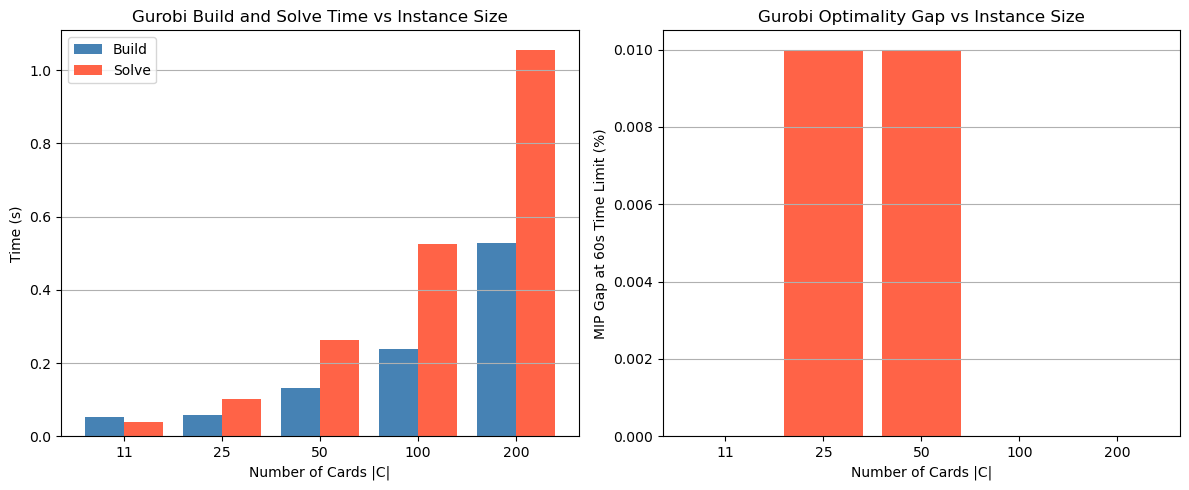

In [6]:
labels = [str(r['|C|']) for r in scale_rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

build_times = [r['Build (s)'] for r in scale_rows]
solve_times = [r['Solve (s)'] for r in scale_rows]
x_pos = range(len(labels))
width = 0.4
ax1.bar([xi - width/2 for xi in x_pos], build_times, width, label='Build', color='steelblue')
ax1.bar([xi + width/2 for xi in x_pos], solve_times, width, label='Solve', color='tomato')
ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(labels)
ax1.set_xlabel('Number of Cards |C|')
ax1.set_ylabel('Time (s)')
ax1.set_title('Gurobi Build and Solve Time vs Instance Size')
ax1.legend()
ax1.grid(True, axis='y')

gaps = [r['Gap (%)'] if r['Gap (%)'] is not None else 0.0 for r in scale_rows]
ax2.bar(labels, gaps, color='tomato')
ax2.set_xlabel('Number of Cards |C|')
ax2.set_ylabel('MIP Gap at 60s Time Limit (%)')
ax2.set_title('Gurobi Optimality Gap vs Instance Size')
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()

## 4. Simulated Annealing

### Algorithm Design

**Solution representation:**
- `wallet` — list of card indices held (length $\leq W$)
- `allocation` — `dict[(month m, category k)] → card index` mapping every category in every month to a card in the wallet

**Objective evaluation** is direct (no solver): compute capped rewards for each (card, month) pair, penalise minimum spend violations, deduct two years of fees. Cost: $O(H \times |W| \times |\mathcal{K}|) = O(432)$ per call.

**Neighbourhood operators** (selected with 30%/70% probability):
1. **Wallet swap** — replace one card in the wallet with a randomly chosen eligible non-wallet card; re-assign the displaced categories to the added card
2. **Category reassign** — pick a random (month, category) pair and move it to a different card in the wallet

**Cooling schedule** (course-style inverse cooling):
$$T(i) = \frac{T_0}{1 + \lambda \cdot i}, \quad T_0 = |f_0|, \quad \lambda = 0.0001$$

**Acceptance criterion** (maximisation Metropolis):
$$\text{accept} \iff \Delta > 0 \;\text{ or }\; \text{Uniform}(0,1) < e^{\Delta / T}$$
where $\Delta = f_{\text{new}} - f_{\text{current}}$. Worse moves are accepted with probability decaying as $T \to 0$.

In [ ]:
def evaluate_objective(wallet, allocation, cards, spend_matrix, penalty=1e4):
    total = 0.0
    for ci in wallet:
        card = cards[ci]
        for m in range(H):
            routed = 0.0
            reward = 0.0
            for k in CATEGORIES:
                if allocation[(m, k)] == ci:
                    s       = float(spend_matrix[k][m])
                    routed += s
                    reward += min(card.rates[k] * s, card.category_caps[k])
            if routed >= card.min_spend - 1e-6:
                total += min(reward, card.overall_cap)
            elif routed > 0:
                total -= penalty * (card.min_spend - routed)
    total -= 2.0 * sum(cards[ci].annual_fee for ci in wallet)
    return total

def greedy_initial(cards, spend_matrix, W_max=W_MAX, income=60_000):
    eligible = [i for i, c in enumerate(cards) if income >= c.min_income]
    monthly_totals = [sum(float(spend_matrix[k][m]) for k in CATEGORIES) for m in range(H)]
    min_monthly = min(monthly_totals)

    def card_score(ci):
        c = cards[ci]
        feasible = [m for m in range(H) if monthly_totals[m] >= c.min_spend]
        if len(feasible) < H // 2:
            return -1e12
        score = sum(
            min(sum(min(c.rates[k] * float(spend_matrix[k][m]), c.category_caps[k])
                    for k in CATEGORIES), c.overall_cap)
            for m in feasible
        )
        return score - 2.0 * c.annual_fee

    # Build wallet sequentially. At most ONE card with min_spend > 0 is allowed:
    # two cards competing for the same spend budget can deadlock the repair even
    # when their combined min_spend fits within min_monthly, because categories
    # are discrete and cannot be split across cards.
    ranked = sorted(eligible, key=card_score, reverse=True)
    wallet = []
    has_min_spend_card = False
    for ci in ranked:
        if len(wallet) >= W_max:
            break
        if cards[ci].min_spend > 0:
            if has_min_spend_card or cards[ci].min_spend > min_monthly:
                continue   # skip: would create competing or infeasible min_spend
            has_min_spend_card = True
        wallet.append(ci)

    allocation = {}
    for m in range(H):
        for k in CATEGORIES:
            allocation[(m, k)] = max(wallet, key=lambda ci: cards[ci].rates[k])

    # Repair: route enough categories to the one min_spend card per month.
    # Multi-pass is a safety net (single card means one pass always suffices).
    for _ in range(2):
        changed = False
        for m in range(H):
            for ci in wallet:
                if cards[ci].min_spend == 0:
                    continue
                routed = sum(float(spend_matrix[k][m]) for k in CATEGORIES
                             if allocation[(m, k)] == ci)
                if routed < cards[ci].min_spend - 1e-6:
                    others = [k for k in CATEGORIES if allocation[(m, k)] != ci]
                    others.sort(
                        key=lambda kk: cards[ci].rates[kk] - cards[allocation[(m, kk)]].rates[kk],
                        reverse=True
                    )
                    for kk in others:
                        if routed >= cards[ci].min_spend:
                            break
                        routed += float(spend_matrix[kk][m])
                        allocation[(m, kk)] = ci
                        changed = True
        if not changed:
            break

    return wallet, allocation

def wallet_swap(wallet, allocation, cards, income, rng, spend_matrix=None):
    eligible = [i for i, c in enumerate(cards) if income >= c.min_income]
    not_in   = [i for i in eligible if i not in wallet]
    if not not_in:
        return wallet, allocation
    remove     = rng.choice(wallet)
    add        = rng.choice(not_in)
    new_wallet = [c for c in wallet if c != remove] + [add]
    new_alloc  = {key: (add if ci == remove else ci) for key, ci in allocation.items()}
    # Repair min_spend for the newly added card
    if spend_matrix is not None and cards[add].min_spend > 0:
        for m in range(H):
            routed = sum(float(spend_matrix[k][m]) for k in CATEGORIES
                         if new_alloc[(m, k)] == add)
            if routed < cards[add].min_spend:
                others = [k for k in CATEGORIES if new_alloc[(m, k)] != add]
                others.sort(
                    key=lambda kk: cards[add].rates[kk] - cards[new_alloc[(m, kk)]].rates[kk],
                    reverse=True
                )
                for kk in others:
                    if routed >= cards[add].min_spend:
                        break
                    routed += float(spend_matrix[kk][m])
                    new_alloc[(m, kk)] = add
    return new_wallet, new_alloc

def category_reassign(wallet, allocation, rng):
    m      = rng.randint(0, H - 1)
    k      = rng.choice(CATEGORIES)
    others = [ci for ci in wallet if ci != allocation[(m, k)]]
    if not others:
        return wallet, allocation
    new_alloc        = dict(allocation)
    new_alloc[(m, k)] = rng.choice(others)
    return wallet, new_alloc


In [8]:
def simulated_annealing(cards, spend_matrix, income=60_000, W_max=W_MAX,
                        T0=None, lam=0.0001, max_iter=None, seed=42):
    rng = random.Random(seed)

    wallet, allocation = greedy_initial(cards, spend_matrix, W_max, income)
    current_obj = evaluate_objective(wallet, allocation, cards, spend_matrix)
    best_wallet = copy.copy(wallet)
    best_alloc  = copy.copy(allocation)
    best_obj    = current_obj

    # Scale budget proportionally to eligible search space
    if max_iter is None:
        n_eligible = sum(1 for c in cards if income >= c.min_income)
        max_iter = max(200_000, int(200_000 * n_eligible / 11))

    if T0 is None:
        # Use greedy objective if feasible; otherwise fall back to reward-scale estimate
        T0 = max(current_obj, 1.0) if current_obj > 0 else 2000.0
    T = T0

    objvaluelist = [best_obj]
    cputimelist  = [0.0]
    start_time   = time.time()

    for i in range(1, max_iter + 1):
        if rng.random() < 0.30:
            new_wallet, new_alloc = wallet_swap(wallet, allocation, cards, income, rng, spend_matrix)
        else:
            new_wallet, new_alloc = category_reassign(wallet, allocation, rng)

        new_obj = evaluate_objective(new_wallet, new_alloc, cards, spend_matrix)
        delta   = new_obj - current_obj

        # Metropolis acceptance (maximisation)
        if delta > 0 or rng.random() < math.exp(delta / T):
            wallet, allocation, current_obj = new_wallet, new_alloc, new_obj
            if current_obj > best_obj:
                best_wallet = copy.copy(wallet)
                best_alloc  = copy.copy(allocation)
                best_obj    = current_obj
                objvaluelist.append(best_obj)
                cputimelist.append(time.time() - start_time)

        # Cooling schedule: T = T0 / (1 + lam * i)
        T = T0 / (1 + lam * i)

        if i % 10_000 == 0:
            clear_output(wait=True)
            print(f'Iter {i:>7d} | T = {T:.2f} | Current = {current_obj:.2f} | Best = {best_obj:.2f}')

    objvaluelist.append(best_obj)
    cputimelist.append(time.time() - start_time)
    return best_wallet, best_alloc, best_obj, objvaluelist, cputimelist

### 4.1 SA on Base Instance — 11 Real Cards

Run SA on the same base instance as Section 2.1 to verify that it finds a solution close to the Gurobi optimal, then plot the convergence curve.

In [9]:
random.seed(42)
cards_base, spend_base = build_instance(n_extra=0)

w0, a0 = greedy_initial(cards_base, spend_base)
greedy_obj = evaluate_objective(w0, a0, cards_base, spend_base)

best_w, best_a, best_obj_sa, objlist, timelist = simulated_annealing(cards_base, spend_base)

print(f'Greedy initial:       S${greedy_obj:.2f}')
print(f'SA best:              S${best_obj_sa:.2f}')
print(f'Gurobi optimal:       S${result["obj_val"]:.2f}')
if result['obj_val'] and result['obj_val'] > 0:
    gap = (result['obj_val'] - best_obj_sa) / result['obj_val'] * 100
    print(f'SA gap from optimal:  {gap:.2f}%')
print(f'SA wallet:  {[cards_base[ci].name for ci in best_w]}')

Iter  200000 | T = 108.60 | Current = 1117.69 | Best = 2417.90
Greedy initial:       S$2280.68
SA best:              S$2417.90
Gurobi optimal:       S$2553.22
SA gap from optimal:  5.30%
SA wallet:  ['HSBC Revolution Credit Card', 'Cashback Credit Card by Trust', 'UOB EVOL Credit Card']


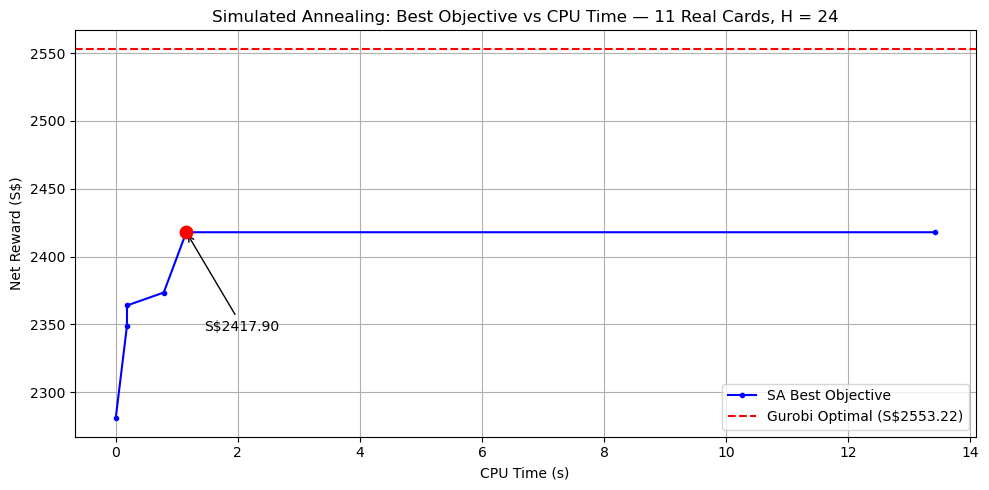

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(timelist, objlist, color='blue', marker='o', markersize=3,
         label='SA Best Objective')

if result['obj_val']:
    plt.axhline(result['obj_val'], color='red', linestyle='--', linewidth=1.5,
                label=f'Gurobi Optimal (S${result["obj_val"]:.2f})')

max_idx = objlist.index(max(objlist))
plt.scatter([timelist[max_idx]], [objlist[max_idx]], color='red', s=80, zorder=5)
plt.annotate(f'S${objlist[max_idx]:.2f}',
             xy=(timelist[max_idx], objlist[max_idx]),
             xytext=(timelist[max_idx] + 0.3, objlist[max_idx] * 0.97),
             arrowprops=dict(arrowstyle='->'))

plt.xlabel('CPU Time (s)')
plt.ylabel('Net Reward (S$)')
plt.title('Simulated Annealing: Best Objective vs CPU Time — 11 Real Cards, H = 24')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Benchmark Comparison

Run both Gurobi and SA on instances of size $|\mathcal{C}| \in \{11, 25, 50\}$ with a 60-second time limit each. For instances where Gurobi finds the optimal, the SA gap is computed as:

$$\text{SA gap} = \frac{f^* - f_{\text{SA}}}{f^*} \times 100\%$$

For larger instances where Gurobi hits the time limit, we compare against its best bound.

In [11]:
random.seed(1)
bench_sizes   = [11, 25, 50]
bench_rows    = []
sa_histories  = {}

for n in bench_sizes:
    cards_n, spend_n = build_instance(n_extra=n - 11)

    gr = solve_milp(cards_n, spend_n, time_limit=60)
    _, _, sa_obj, sa_ol, sa_tl = simulated_annealing(cards_n, spend_n, seed=42)

    reference = gr['obj_val'] if gr['obj_val'] else gr['best_bound']
    gap_pct   = round((reference - sa_obj) / reference * 100, 2) if reference and reference > 0 else None

    bench_rows.append({
        '|C|':           n,
        'Gurobi (S$)':   gr['obj_val'],
        'Gurobi status': gr['status'],
        'SA (S$)':       round(sa_obj, 2),
        'SA gap (%)':    gap_pct,
        'Gurobi time':   gr['solve_time'],
        'SA time (s)':   round(sa_tl[-1], 1),
    })
    sa_histories[n] = (sa_ol, sa_tl)
    print(f'|C|={n}  Gurobi={gr["obj_val"]}  SA={sa_obj:.2f}  gap={gap_pct}%')

df_bench = pd.DataFrame(bench_rows)
display(df_bench)

Iter  900000 | T = 21.98 | Current = 2079.07 | Best = 2192.90
|C|=50  Gurobi=2553.22  SA=2192.90  gap=14.11%


,|C|,Gurobi (S$),Gurobi status,SA (S$),SA gap (%),Gurobi time,SA time (s)
0,11,2553.22,OPTIMAL,2417.90,5.30,0.039,13.7
1,25,2553.22,OPTIMAL,2294.87,10.12,0.104,34.3
2,50,2553.22,OPTIMAL,2192.90,14.11,0.268,69.7


## 6. SA vs Greedy — Visual Analysis

Three panels:
- **Left** — SA convergence from the greedy starting point for each instance size; dotted line = greedy initial (same for all sizes since the feasible wallet is identical); shows how quickly SA escapes the greedy plateau.
- **Centre** — Absolute solution quality (Gurobi / SA / Greedy) per instance size.
- **Right** — Gap from Gurobi optimal for Greedy vs SA; SA narrows the gap compared to greedy but leaves a residual that grows with instance size.


In [ ]:
# Validated palette — categorical slots 1–3, surface, grid, ink
C_GUROBI = '#2a78d6'   # blue  – slot 1 (reference / optimal)
C_SA     = '#1baf7a'   # aqua  – slot 2 (SA result)
C_GREEDY = '#eda100'   # amber – slot 3 (greedy initial)
C_SURF   = '#fcfcfb'
C_GRID   = '#e1e0d9'
C_INK    = '#0b0b0b'
C_MUTED  = '#898781'
C_AX     = '#c3c2b7'

GUROBI_VALS = {11: 2553.22, 25: 2553.22, 50: 2553.22}
BENCH_SIZES = [11, 25, 50]

def _run_tracked(cards, spend_matrix, seed=42, n_checkpoints=400):
    """SA with greedy start; returns greedy_obj, best_obj, and sampled trajectory."""
    import random as _rnd, math as _math, copy as _copy
    rng = _rnd.Random(seed)
    wallet, allocation = greedy_initial(cards, spend_matrix)
    current_obj = evaluate_objective(wallet, allocation, cards, spend_matrix)
    greedy_obj  = current_obj
    best_obj    = current_obj
    best_wallet = _copy.copy(wallet)
    best_alloc  = _copy.copy(allocation)

    n_eligible = sum(1 for c in cards if 60_000 >= c.min_income)
    max_iter   = max(200_000, int(200_000 * n_eligible / 11))
    T0         = max(current_obj, 1.0) if current_obj > 0 else 2000.0
    T          = T0
    lam        = 0.0001

    every     = max(1, max_iter // n_checkpoints)
    iters_out = []
    best_out  = []

    for i in range(1, max_iter + 1):
        if rng.random() < 0.30:
            nw, na = wallet_swap(wallet, allocation, cards, 60_000, rng, spend_matrix)
        else:
            nw, na = category_reassign(wallet, allocation, rng)
        new_obj = evaluate_objective(nw, na, cards, spend_matrix)
        delta   = new_obj - current_obj
        if delta > 0 or rng.random() < _math.exp(delta / T):
            wallet, allocation, current_obj = nw, na, new_obj
            if current_obj > best_obj:
                best_obj    = current_obj
                best_wallet = _copy.copy(wallet)
                best_alloc  = _copy.copy(allocation)
        T = T0 / (1 + lam * i)
        if i % every == 0:
            iters_out.append(i)
            best_out.append(best_obj)

    return greedy_obj, best_obj, iters_out, best_out

# Collect data
random.seed(1)
viz_data = {}
for _n in BENCH_SIZES:
    _cards, _spend = build_instance(n_extra=_n - 11)
    _g, _s, _iters, _traj = _run_tracked(_cards, _spend, seed=42)
    viz_data[_n] = dict(greedy=_g, sa=_s, gurobi=GUROBI_VALS[_n],
                         iters=_iters, traj=_traj)
    print(f'|C|={_n:2d}  greedy={_g:>8.2f}  SA={_s:>8.2f}  '
          f'gap={(GUROBI_VALS[_n] - _s)/GUROBI_VALS[_n]*100:.1f}%')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(C_SURF)

for ax in axes:
    ax.set_facecolor(C_SURF)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(C_AX)
    ax.tick_params(colors=C_MUTED, labelsize=9)
    ax.yaxis.grid(True, color=C_GRID, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

# ── Panel 1: convergence curves ───────────────────────────────────────────────
ax1 = axes[0]
_size_colors = {11: C_SA, 25: C_GUROBI, 50: C_GREEDY}

for _n in BENCH_SIZES:
    d = viz_data[_n]
    col = _size_colors[_n]
    ax1.plot(d['iters'], d['traj'], color=col, linewidth=1.8,
             label=f'|C|={_n}', zorder=3)

# Greedy initial is the same across all sizes — one shared reference line
_greedy_ref = viz_data[11]['greedy']
ax1.axhline(_greedy_ref, color=C_GREEDY, linewidth=1.0,
            linestyle=':', alpha=0.7, zorder=2)
ax1.text(viz_data[11]['iters'][5], _greedy_ref - 55,
         f'Greedy start ({_greedy_ref:.0f})',
         fontsize=7.5, color=C_MUTED, va='top')

ax1.axhline(2553.22, color=C_MUTED, linewidth=1.2,
            linestyle='--', zorder=2, alpha=0.7)
ax1.text(viz_data[11]['iters'][-1] * 0.97, 2590,
         'Gurobi', ha='right', fontsize=7.5, color=C_MUTED)
ax1.set_ylim(max(0, _greedy_ref - 200), 3050)
ax1.set_xlabel('Iteration', color=C_MUTED, fontsize=9)
ax1.set_ylabel('Best objective (S$)', color=C_MUTED, fontsize=9)
ax1.set_title('SA Convergence from Greedy Start', color=C_INK,
              fontsize=10, fontweight='bold', pad=10)
ax1.legend(fontsize=8.5, frameon=False, loc='lower right')

# ── Panel 2: absolute quality grouped bar ────────────────────────────────────
ax2 = axes[1]
_x = np.arange(len(BENCH_SIZES))
_w = 0.24

_bars = ax2.bar(_x - _w, [viz_data[n]['gurobi'] for n in BENCH_SIZES],
                 _w - 0.02, color=C_GUROBI, label='Gurobi', zorder=3)
for b in _bars:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
             f'{b.get_height():.0f}', ha='center', va='bottom',
             fontsize=7.5, color=C_INK)

_bars = ax2.bar(_x, [viz_data[n]['sa'] for n in BENCH_SIZES],
                 _w - 0.02, color=C_SA, label='SA', zorder=3)
for b in _bars:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
             f'{b.get_height():.0f}', ha='center', va='bottom',
             fontsize=7.5, color=C_INK)

_bars = ax2.bar(_x + _w, [viz_data[n]['greedy'] for n in BENCH_SIZES],
                 _w - 0.02, color=C_GREEDY, label='Greedy', zorder=3)
for b in _bars:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
             f'{b.get_height():.0f}', ha='center', va='bottom',
             fontsize=7.5, color=C_INK)

ax2.set_xticks(_x)
ax2.set_xticklabels([f'|C|={n}' for n in BENCH_SIZES])
ax2.set_ylim(0, 3200)
ax2.set_ylabel('Net reward (S$, 24 months)', color=C_MUTED, fontsize=9)
ax2.set_title('Solution Quality by Instance Size', color=C_INK,
              fontsize=10, fontweight='bold', pad=10)
ax2.legend(fontsize=8.5, frameon=False)

# ── Panel 3: gap from Gurobi ──────────────────────────────────────────────────
ax3 = axes[2]

_gap_greedy = [(v['gurobi'] - v['greedy']) / v['gurobi'] * 100 for v in viz_data.values()]
_gap_sa     = [(v['gurobi'] - v['sa'])     / v['gurobi'] * 100 for v in viz_data.values()]

_bars = ax3.bar(_x - _w/2, _gap_greedy, _w - 0.02,
                 color=C_GREEDY, label='Greedy', zorder=3)
for b, gap in zip(_bars, _gap_greedy):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f'{gap:.1f}%', ha='center', va='bottom', fontsize=8, color=C_INK)

_bars = ax3.bar(_x + _w/2, _gap_sa, _w - 0.02,
                 color=C_SA, label='SA', zorder=3)
for b, gap in zip(_bars, _gap_sa):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f'{gap:.1f}%', ha='center', va='bottom', fontsize=8, color=C_INK)

ax3.set_xticks(_x)
ax3.set_xticklabels([f'|C|={n}' for n in BENCH_SIZES])
ax3.set_ylim(0, max(_gap_greedy) * 1.25)
ax3.set_ylabel('Gap from Gurobi optimal (%)', color=C_MUTED, fontsize=9)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax3.set_title('Optimality Gap: Greedy vs SA', color=C_INK,
              fontsize=10, fontweight='bold', pad=10)
ax3.legend(fontsize=8.5, frameon=False)

fig.suptitle('SA vs Greedy: Convergence, Solution Quality, and Optimality Gap',
             fontsize=11, fontweight='bold', color=C_INK, y=1.02)
plt.tight_layout()
plt.show()


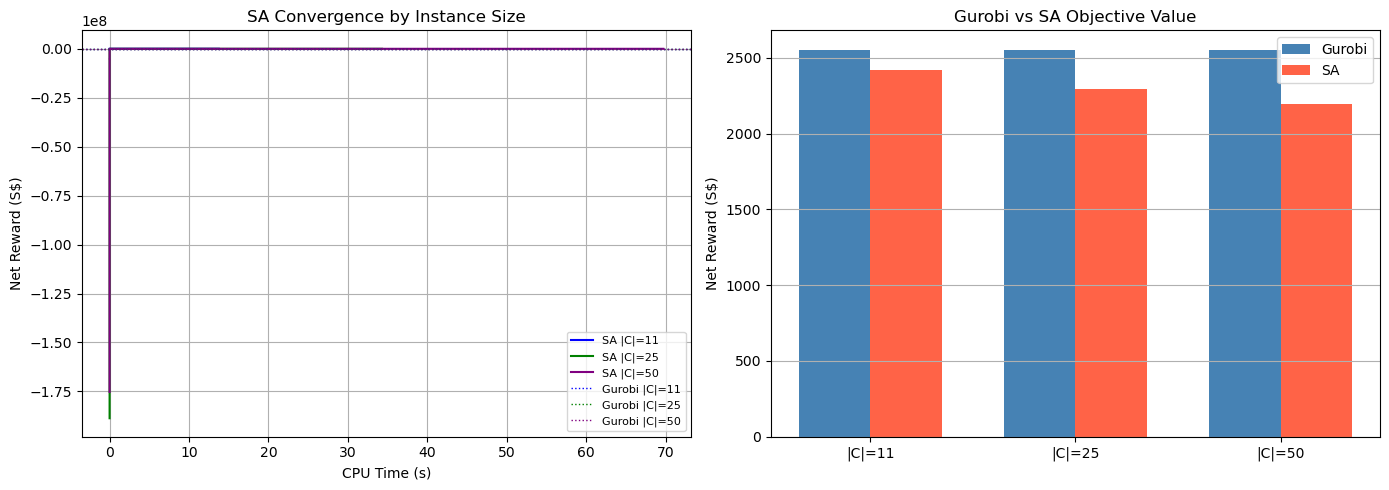

In [12]:
colors = ['blue', 'green', 'purple']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: SA convergence curves
for (n, (ol, tl)), col in zip(sa_histories.items(), colors):
    ax1.plot(tl, ol, color=col, linewidth=1.5, label=f'SA |C|={n}')

for row, col in zip(bench_rows, colors):
    ref = row['Gurobi (S$)']
    if ref:
        ax1.axhline(ref, color=col, linestyle=':', linewidth=1,
                    label=f'Gurobi |C|={row["|C|"]}')

ax1.set_xlabel('CPU Time (s)')
ax1.set_ylabel('Net Reward (S$)')
ax1.set_title('SA Convergence by Instance Size')
ax1.legend(fontsize=8)
ax1.grid(True)

# Right: grouped bar chart
x     = list(range(len(bench_rows)))
width = 0.35
ax2.bar([xi - width/2 for xi in x],
        [r['Gurobi (S$)'] or 0 for r in bench_rows],
        width, label='Gurobi', color='steelblue')
ax2.bar([xi + width/2 for xi in x],
        [r['SA (S$)'] for r in bench_rows],
        width, label='SA', color='tomato')
ax2.set_xticks(x)
ax2.set_xticklabels([f'|C|={r["|C|"]}'for r in bench_rows])
ax2.set_ylabel('Net Reward (S$)')
ax2.set_title('Gurobi vs SA Objective Value')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()